In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

In [2]:
import os
import pandas as pd
import numpy as np
import random
from collections import deque

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Import class custom từ file của bạn
from Bert4Rec_model import BERT4Rec, gather_indexes

RATING_FILE_PATH = r'F:\1_REL\Reinforcement-learning-for-Recommendation\Data_Movielens_1m\ml-1m\ratings.dat'
MODEL_WEIGHT_PATH = r'F:\1_REL\Reinforcement-learning-for-Recommendation\saved_models\bert4rec_best.pth'

# LOAD DATA  +  PREPROCESS ML-1M

In [3]:
def load_offline_data_custom(rating_file_path, max_history_len=200, min_history_len=5):
    print(f"[*] Đang tải dữ liệu từ {rating_file_path} ...")

    ratings_cols = ['UserID', 'MovieID', 'Rating', 'Timestamp']
    ratings = pd.read_csv(rating_file_path, sep='::', engine='python', names=ratings_cols)
    ratings = ratings.sort_values(by=['UserID', 'Timestamp']).reset_index(drop=True)

    raw_movie_ids = sorted(ratings['MovieID'].unique())
    movie2id = {raw_id: i + 1 for i, raw_id in enumerate(raw_movie_ids)}
    ratings['Movie_Encoded'] = ratings['MovieID'].map(movie2id)

    print("[*] Đang gom nhóm thành lịch sử Sequence...")

    # Gom cả (movie_encoded, rating) theo từng user
    ratings['pair'] = list(zip(ratings['Movie_Encoded'], ratings['Rating']))
    user_sequences = ratings.groupby('UserID')['pair'].apply(list).to_dict()

    offline_data = []

    for _, seq in user_sequences.items():
        if len(seq) < 3:
            continue

        last_valid_i = None
        for i in range(len(seq) - 1, 0, -1):
            history = [m for m, r in seq[max(0, i - max_history_len):i]]
            if len(history) >= min_history_len:
                last_valid_i = i
                break

        for i in range(1, len(seq)):
            history     = [m for m, r in seq[max(0, i - max_history_len):i]]
            target_item = seq[i][0]
            target_rating = seq[i][1]  # float: 1.0 ~ 5.0
            if len(history) < min_history_len:
                continue

            is_terminal = (i == last_valid_i)

            offline_data.append((history, target_item, target_rating, is_terminal))

    n_terminal = sum(1 for _, _, _, t in offline_data if t)
    print(f"[+] Hoàn tất! Đã tạo được {len(offline_data):,} mẫu Transition.")
    print(f"    → Trong đó {n_terminal:,} terminal transitions ({n_terminal/len(offline_data)*100:.1f}%)")
    return offline_data

# LOAD WEIGHT

In [4]:
# 2. LOAD TRỌNG SỐ CHO BERT4REC TỪ FILE CỦA BẠN
# ==========================================
def load_custom_bert4rec(pth_path, device='cuda'):
    print(f"[*] Đang tải trọng số BERT4Rec từ {pth_path} ...")
    state_dict = torch.load(pth_path, map_location=device, weights_only=True)
    
    # Tính số lượng item từ shape của bảng nhúng (trừ đi dòng padding 0)
    emb_shape = state_dict['item_embedding.weight'].shape
    n_items_from_weights = emb_shape[0] - 1 
    hidden_size = emb_shape[1]
    
    print(f"[*] Cấu hình nhận diện: n_items = {n_items_from_weights}, hidden_size = {hidden_size}")
    
    # Khởi tạo mô hình (thông số khớp với notebook của bạn)
    model = BERT4Rec(
        n_items             = n_items_from_weights, 
        max_seq_length      = 200, 
        hidden_size         = 64,  
        n_layers            = 2, 
        n_heads             = 2, 
        inner_size          = 256
    )
    
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval() # Đóng băng BatchNorm/Dropout
    
    print("[+] Đã load trọng số BERT4Rec thành công!")
    return model


#  STATE  ENCODER

In [5]:
# # 3. STATE ENCODER
# # ==========================================
# class StandaloneStateEncoder(nn.Module):
#     def __init__(self, custom_bert4rec_model):
#         super().__init__()
#         self.bert = custom_bert4rec_model
#         self.hidden_size = self.bert.hidden_size
        
#         # Đóng băng toàn bộ trọng số, chỉ dùng làm Feature Extractor
#         for param in self.bert.parameters():
#             param.requires_grad = False
            
#     def get_state(self, user_history_seqs, max_len=200, device='cuda'):
#         batch_size = len(user_history_seqs)
        
#         item_seq = torch.zeros((batch_size, max_len), dtype=torch.long).to(device)
#         item_seq_len = torch.zeros((batch_size,), dtype=torch.long).to(device)
        
#         for i, seq in enumerate(user_history_seqs):
#             seq_len = min(len(seq), max_len)
#             item_seq_len[i] = seq_len
#             # Ghi lịch sử vào đầu tensor (left-aligned) như file train của bạn
#             item_seq[i, :seq_len] = torch.tensor(seq[-seq_len:], dtype=torch.long)
            
#         with torch.no_grad():
#             # Tự động chèn MASK token
#             prepared_seq = self.bert.reconstruct_test_data(item_seq, item_seq_len)
#             seq_output = self.bert.forward(prepared_seq) 
#             # Trích xuất state vector
#             state_vector = gather_indexes(seq_output, item_seq_len - 1)
            
#         return state_vector


In [6]:
class StandaloneStateEncoder(nn.Module):
    def __init__(self, custom_bert4rec_model):
        super().__init__()
        self.bert = custom_bert4rec_model
        self.hidden_size = self.bert.hidden_size
        for param in self.bert.parameters():
            param.requires_grad = False

    def get_state(self, user_history_seqs, max_len=200, device='cuda'):
        """
        Encode một batch lịch sử thành state vectors.
        Tối ưu: nhận nhiều sequences cùng lúc thay vì từng cái.

        Args:
            user_history_seqs: List[List[int]] — batch các lịch sử item
            max_len: độ dài tối đa của sequence (phải khớp với BERT config)
            device: thiết bị tính toán

        Returns:
        """
        batch_size = len(user_history_seqs)

        item_seq     = torch.zeros((batch_size, max_len), dtype=torch.long, device=device)
        item_seq_len = torch.zeros((batch_size,), dtype=torch.long, device=device)

        for i, seq in enumerate(user_history_seqs):
            seq_len = min(len(seq), max_len)   # không trừ 1
            item_seq_len[i] = seq_len           # không cộng 1
            item_seq[i, :seq_len] = torch.tensor(seq[-seq_len:], dtype=torch.long)

        with torch.no_grad():
            prepared_seq = self.bert.reconstruct_test_data(item_seq, item_seq_len)
            seq_output   = self.bert.forward(prepared_seq)
            # MASK ở vị trí item_seq_len - 1
            state_vector = gather_indexes(seq_output, item_seq_len - 1)

        return state_vector

# ACTOR CRITIC NETWORK

In [7]:
# 4. MẠNG ACTOR & CRITIC
# ==========================================
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, beta=0.05): # beta nhỏ để RL điều chỉnh nhẹ
        super(Actor, self).__init__()
        self.beta = beta 
        
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, action_dim) 
        
        # Khởi tạo trọng số fc3 rất nhỏ để lúc đầu Actor output ~ 0
        nn.init.uniform_(self.fc3.weight, -1e-5, 1e-5)
        nn.init.zeros_(self.fc3.bias)
    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        residual = self.fc3(x)
        
        # Action = State gốc (của BERT) + Một chút tinh chỉnh từ RL
        final_action = state + (self.beta * residual)
        final_action = F.normalize(final_action, p=2, dim=-1)
        return final_action

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        q_value = self.fc3(x)
        return q_value

#  REPLAY BUFFER OFFLINE

In [8]:
# 5. REPLAY BUFFER & MÔI TRƯỜNG OFFLINE
# ==========================================
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done
    
    def __len__(self):
        return len(self.buffer)

# ============================================================
# CLASS SỬA: OfflineRecEnv
# THAY TOÀN BỘ CLASS CŨ BẰNG CLASS NÀY
# ============================================================
class OfflineRecEnv:
    def __init__(self, custom_bert_model, n_negatives=200):   # ← tăng từ 50 → 200
        self.item_embeddings = custom_bert_model.item_embedding.weight.detach()
        self.n_items         = self.item_embeddings.shape[0]
        self.n_negatives     = n_negatives


    def step(self, action_vector, target_item_id, actual_rating=None, n_negatives=50, is_last_step=False):
        
        # Phần 1: Tín hiệu HƯỚNG (Giữ nguyên)
        target_emb = self.item_embeddings[target_item_id]
        cos_pos = F.cosine_similarity(
            action_vector, target_emb.unsqueeze(0)
        ).item()
        
        neg_ids = torch.randint(1, len(self.item_embeddings), (n_negatives,))
        neg_embs = self.item_embeddings[neg_ids]
        cos_neg = F.cosine_similarity(
            action_vector.expand(n_negatives, -1), neg_embs
        ).mean().item()
        
        direction_signal = cos_pos - cos_neg 

        # Phần 2: Hàm Reward An Toàn (Safe Reward)
        if actual_rating is not None and actual_rating >= 4.0:
            # Thưởng thêm 50% nếu rating cao (nhấn mạnh chất lượng)
            reward = direction_signal * 1.5 
        else:
            # Vẫn giữ nguyên tín hiệu tương tác 100%, KHÔNG triệt tiêu về 0
            reward = direction_signal * 1.0 

        return reward, is_last_step


    def step_batch(self, action_matrix, target_item_ids, actual_ratings, device='cuda'):
        B = action_matrix.shape[0]
 
        # --- Positive signal ---
        target_embs = self.item_embeddings[target_item_ids]
        cos_pos = F.cosine_similarity(action_matrix, target_embs, dim=1)  # [B]
 
        # --- Negative signal ---
        neg_ids  = torch.randint(1, self.n_items, (B, self.n_negatives), device=device)
        neg_embs = self.item_embeddings[neg_ids]                         # [B, K, H]
 
        action_expanded = action_matrix.unsqueeze(1).expand(-1, self.n_negatives, -1)
        cos_neg_all  = F.cosine_similarity(action_expanded, neg_embs, dim=2)  # [B, K]
        cos_neg_mean = cos_neg_all.mean(dim=1)                                # [B]
        cos_neg_std  = cos_neg_all.std(dim=1).clamp(min=1e-6)                 # [B]
 
        # FIX 2: normalize reward → không bị collapse về 0
        # Ý nghĩa: "cos_pos cao hơn mean bao nhiêu std?"
        direction_signal = (cos_pos - cos_neg_mean) / cos_neg_std  # [B]
 
        # Rating bonus nhẹ: rating>=4 → +10%, rating<3 → -10%
        # Giữ sign của direction_signal, chỉ điều chỉnh magnitude nhẹ
        rating_weight = torch.where(
            actual_ratings >= 4.0,
            torch.full_like(actual_ratings, 1.1),
            torch.where(
                actual_ratings < 3.0,
                torch.full_like(actual_ratings, 0.9),
                torch.ones_like(actual_ratings),
            )
        )
        rewards = direction_signal * rating_weight  # [B]
 
        return rewards

# OU NOISE

In [9]:
# ============================================================
# CLASS MỚI: OUNoise — thêm vào trước train_rl_model()
# ============================================================
class OUNoise:
    """
    Ornstein-Uhlenbeck Noise cho continuous action space.
    Noise có 'memory' — drift có hướng rồi kéo về 0.
    Phù hợp hơn Gaussian thuần cho vector 64 chiều.
    """
    def __init__(self, action_dim, mu=0.0, theta=0.15, sigma=0.05, sigma_min=0.05, decay=0.995):
        self.action_dim = action_dim
        self.mu         = mu        # điểm kéo về (mean)
        self.theta      = theta     # lực kéo về mu
        self.sigma      = sigma     # độ lớn noise ban đầu
        self.sigma_min  = sigma_min # noise tối thiểu — không giảm về 0
        self.decay      = decay     # tốc độ giảm sigma mỗi episode
        self.state      = np.ones(action_dim) * mu

    def reset(self):
        """Reset state về mu — gọi đầu mỗi epoch."""
        self.state = np.ones(self.action_dim) * self.mu

    def decay_sigma(self):
        """Giảm sigma sau mỗi epoch, nhưng không xuống dưới sigma_min."""
        self.sigma = max(self.sigma_min, self.sigma * self.decay)

    def sample(self):
        """Sinh một noise vector theo OU process."""
        dx = self.theta * (self.mu - self.state) + \
             self.sigma * np.random.randn(self.action_dim)
        self.state = self.state + dx
        return self.state.copy()

    def __repr__(self):
        return f"OUNoise(sigma={self.sigma:.4f}, sigma_min={self.sigma_min}, theta={self.theta})"

In [10]:
# ============================================================
# CLASS MỚI: OfflineRLDataset
# Thêm vào trước train_rl_model()
# ============================================================
class OfflineRLDataset(torch.utils.data.Dataset):
    """
    Dataset wrapper cho offline_data.
    Trả về (history, target_item, target_rating, is_terminal)
    cho từng sample — không precompute state vào RAM.
    State sẽ được encode on-the-fly trong DataLoader.
    """
    def __init__(self, offline_data):
        self.data = offline_data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        history, target_item, target_rating, is_terminal = self.data[idx]
        return history, target_item, target_rating, is_terminal


def collate_fn(batch):
    """
    Custom collate: pad history sequences về cùng độ dài trong batch.
    """
    histories, target_items, target_ratings, is_terminals = zip(*batch)

    # Pad history về max_len trong batch này
    max_len = max(len(h) for h in histories)
    padded  = [h + [0] * (max_len - len(h)) for h in histories]

    return (
        padded,                                          # list of lists
        list(target_items),                              # list of int
        torch.FloatTensor(target_ratings),               # [B]
        torch.FloatTensor([float(t) for t in is_terminals])  # [B]
    )

In [11]:
# from tqdm import tqdm
# import matplotlib.pyplot as plt
# def encode_state(history_list, encoder, device, max_len=200):
#     """Encode một history list thành state vector."""
#     history_tensor = torch.tensor(
#         history_list[-max_len:], dtype=torch.long
#     ).unsqueeze(0).to(device)                      # [1, seq_len]

#     with torch.no_grad():
#         state = encoder(history_tensor)            # [1, hidden_size]
#     return state.squeeze(0)
# def train_rl_model(offline_data, custom_bert, device, epochs=20, batch_size=256):

#     encoder = StandaloneStateEncoder(custom_bert).to(device)
#     env     = OfflineRecEnv(custom_bert)

#     state_dim  = encoder.hidden_size
#     action_dim = encoder.hidden_size
#     ou_noise = OUNoise(
#         action_dim = action_dim,
#         sigma      = 0.2,    # noise ban đầu — đủ mạnh để explore
#         sigma_min  = 0.05,   # noise tối thiểu — luôn giữ explore
#         theta      = 0.15,   # lực kéo về 0
#         decay      = 0.995   # giảm ~0.5% mỗi epoch
#      )
#     print(f"[*] OUNoise khởi tạo: {ou_noise}")

#     actor         = Actor(state_dim, action_dim, beta=0.5).to(device)
#     critic        = Critic(state_dim, action_dim).to(device)
#     target_actor  = Actor(state_dim, action_dim, beta=0.5).to(device)
#     target_critic = Critic(state_dim, action_dim).to(device)

#     target_actor.load_state_dict(actor.state_dict())
#     target_critic.load_state_dict(critic.state_dict())

#     actor_optimizer  = optim.Adam(actor.parameters(),  lr=1e-4)
#     critic_optimizer = optim.Adam(critic.parameters(), lr=1e-4)
#     buffer = ReplayBuffer(capacity=500000)

#     history_actor_loss  = []
#     history_critic_loss = []
#     gamma            = 0.99
#     tau              = 0.005
#     SUBSET_SIZE      = 100000
#     UPDATE_EVERY     = 10
#     PRECOMPUTE_BATCH = 512
#     CRITIC_WARMUP    = 2000   # [FIX 2] số update critic trước khi bật actor
#     Q_CLIP           = 10.0   # [FIX 3] ngưỡng clip Q-target

#     print(f"\n[*] Bắt đầu train RL trên {device}...")

#     # Precompute 1 lần
#     print(f"[*] Precomputing {SUBSET_SIZE:,} state vectors (1 lần duy nhất)...")
#     fixed_subset = random.sample(offline_data, SUBSET_SIZE)

#     all_seqs = [h for h, _, _ in fixed_subset] + \
#                [(h + [t])[-200:] for h, t, _ in fixed_subset]

#     all_states_list = []
#     for i in tqdm(range(0, len(all_seqs), PRECOMPUTE_BATCH), desc="  Precomputing", unit="batch"):
#         batch  = all_seqs[i : i + PRECOMPUTE_BATCH]
#         states = encoder.get_state(batch, device=device)
#         all_states_list.append(states.cpu())

#     all_states_cpu   = torch.cat(all_states_list, dim=0)
#     state_cache      = all_states_cpu[:SUBSET_SIZE]
#     next_state_cache = all_states_cpu[SUBSET_SIZE:]
#     print(f"[+] Precompute xong! RAM: ~{all_states_cpu.nbytes/1e6:.0f} MB")

#     total_updates = 0  # [FIX 2] đếm tổng update để kiểm soát warm-up

#     for epoch in range(epochs):
#         ou_noise.reset()        # ✅ reset state OU về mu=0
#         ou_noise.decay_sigma()  # ✅ giảm sigma sau mỗi epoch
#         print(f"  [Noise] sigma hiện tại: {ou_noise.sigma:.4f}")

#         indices = list(range(SUBSET_SIZE))
#         random.shuffle(indices)

#         epoch_actor_loss  = 0
#         epoch_critic_loss = 0
#         num_updates       = 0
#         actor_updates     = 0  # [FIX 2] đếm riêng để tính avg đúng

#         # [FIX 5] enumerate(tqdm(indices)) — tường minh hơn enumerate(step_bar)
#         for step_idx, data_idx in enumerate(tqdm(
#             indices,
#             desc=f"  Epoch {epoch+1:02d}/{epochs}",
#             unit="step",
#             leave=True
#         )):
#             _, target_item, target_rating, is_terminal = fixed_subset[data_idx]

#             state_tensor      = state_cache[data_idx].unsqueeze(0).to(device)
#             next_state_tensor = next_state_cache[data_idx].unsqueeze(0).to(device)

#             noise_std = max(0.01, 0.1 * (1.0 - epoch / epochs))

#             # [FIX 2] action trong exploration không cần gradient
#             with torch.no_grad():
#                 action_tensor = actor(state_tensor)
#                 ou_sample     = torch.FloatTensor(ou_noise.sample()).unsqueeze(0).to(device)
#                 action_tensor = action_tensor + ou_sample
#             # [FIX 1] is_last_step=True → done=1.0 → triệt tiêu Q-bootstrap vô hạn
#             reward, _ = env.step(
#                 action_tensor,
#                 target_item,
#                 is_last_step=is_terminal,       # ← FIX 1
#                 actual_rating=target_rating,
#             )

#             buffer.push(
#                 state_tensor.cpu().numpy()[0],
#                 action_tensor.detach().cpu().numpy()[0],
#                 reward,
#                 next_state_tensor.cpu().numpy()[0],
#                 float(is_terminal),                     # ← FIX 1: done luôn = 1.0
#             )

#             if len(buffer) > batch_size and step_idx % UPDATE_EVERY == 0:
#                 s, a, r, s_next, d = buffer.sample(batch_size)
#                 s, a, r, s_next, d = [torch.FloatTensor(x).to(device)
#                                        for x in [s, a, r, s_next, d]]

#                 with torch.no_grad():
#                     a_next        = target_actor(s_next)
#                     q_target_next = target_critic(s_next, a_next)                    # [B, 1]
#                     q_target      = r.unsqueeze(1) + \
#                                     (1 - d.unsqueeze(1)) * gamma * q_target_next     # [B, 1]
#                     q_target      = torch.clamp(q_target, -Q_CLIP, Q_CLIP)           # ← FIX 3

#                 q_current   = critic(s, a)                                           # [B, 1]
#                 critic_loss = F.mse_loss(q_current, q_target)

#                 critic_optimizer.zero_grad()
#                 critic_loss.backward()
#                 torch.nn.utils.clip_grad_norm_(critic.parameters(), max_norm=0.5)
#                 critic_optimizer.step()

#                 # [FIX 2] chỉ update actor sau khi critic warm-up xong
#                 if total_updates >= CRITIC_WARMUP:
#                     actor_loss = -critic(s, actor(s)).mean()

#                     actor_optimizer.zero_grad()
#                     actor_loss.backward()
#                     torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=0.5)
#                     actor_optimizer.step()

#                     epoch_actor_loss += actor_loss.item()
#                     actor_updates    += 1

#                 for tp, p in zip(target_actor.parameters(), actor.parameters()):
#                     tp.data.copy_(tau * p.data + (1.0 - tau) * tp.data)
#                 for tp, p in zip(target_critic.parameters(), critic.parameters()):
#                     tp.data.copy_(tau * p.data + (1.0 - tau) * tp.data)

#                 epoch_critic_loss += critic_loss.item()
#                 num_updates       += 1
#                 total_updates     += 1

#         if num_updates > 0:
#             avg_c = epoch_critic_loss / num_updates
#             avg_a = epoch_actor_loss  / actor_updates if actor_updates > 0 else float("nan")
#             history_critic_loss.append(avg_c)
#             if actor_updates > 0:
#                 history_actor_loss.append(avg_a)

#             actor_str   = f"{avg_a:.4f}" if actor_updates > 0 else "warming up..."
#             warmup_note = f"  [{max(0, CRITIC_WARMUP - total_updates)} critic updates còn lại]" \
#                           if total_updates < CRITIC_WARMUP else ""
#             print(f"  ✅ Epoch {epoch+1:02d}/{epochs} | Critic: {avg_c:.4f} | Actor: {actor_str}{warmup_note}")

#     plt.figure(figsize=(12, 5))
#     plt.subplot(1, 2, 1)
#     plt.plot(history_actor_loss, label='Actor Loss', color='blue', linewidth=2)
#     plt.title('Actor Loss')
#     plt.xlabel('Epochs')
#     plt.ylabel('Loss')
#     plt.grid(True, linestyle='--', alpha=0.6)
#     plt.legend()

#     plt.subplot(1, 2, 2)
#     plt.plot(history_critic_loss, label='Critic Loss', color='red', linewidth=2)
#     plt.title('Critic Loss')
#     plt.xlabel('Epochs')
#     plt.ylabel('Loss')
#     plt.grid(True, linestyle='--', alpha=0.6)
#     plt.legend()

#     plt.tight_layout()
#     plt.show()

#     return actor, encoder

In [12]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

def train_rl_model(
    offline_data,
    custom_bert,
    device,
    epochs=100,
    batch_size=256,
    test_data=None,
    patience=8,               # FIX 4: tăng từ 3 → 8 (RL cần patience cao hơn)
    val_every=3,              # FIX 3: validate mỗi 3 epoch, không phải mỗi epoch
):
    """
    Các thay đổi so với bản gốc:
      - patience=8 (default) thay vì 3
      - val_every=3: validate mỗi 3 epoch để tránh noise sớm
      - Dùng evaluate_rl_actor_sampled (nhanh) trong training loop
      - Early stopping theo Hit@10 thay vì NDCG@10 (dễ cải thiện hơn ở giai đoạn đầu)
      - FIX 5: current_best_metric có default=0.0 và logic early stopping nằm đúng scope
      - EMA (Exponential Moving Average) của metric để smooth noise
      - Full-rank evaluation chỉ chạy 1 lần sau khi training kết thúc
    """
    from Bert4Rec_model import BERT4Rec, gather_indexes  # import giữ nguyên như cũ
 
    # --- Khởi tạo components ---
    encoder = StandaloneStateEncoder(custom_bert).to(device)
    env     = OfflineRecEnv(custom_bert, n_negatives=200)  # FIX 2
 
    state_dim  = encoder.hidden_size
    action_dim = encoder.hidden_size
 
    ou_noise = OUNoise(
        action_dim=action_dim,
        sigma=0.2,
        sigma_min=0.05,
        theta=0.15,
        decay=0.995,
    )
    print(f"[*] OUNoise khởi tạo: {ou_noise}")
 
    actor         = Actor(state_dim, action_dim, beta=0.5).to(device)
    critic        = Critic(state_dim, action_dim).to(device)
    target_actor  = Actor(state_dim, action_dim, beta=0.5).to(device)
    target_critic = Critic(state_dim, action_dim).to(device)
 
    target_actor.load_state_dict(actor.state_dict())
    target_critic.load_state_dict(critic.state_dict())
 
    actor_optimizer  = optim.Adam(actor.parameters(),  lr=1e-4)
    critic_optimizer = optim.Adam(critic.parameters(), lr=1e-4)
    buffer = ReplayBuffer(capacity=500_000)
 
    history_actor_loss  = []
    history_critic_loss = []
    gamma         = 0.99
    tau           = 0.005
    UPDATE_EVERY  = 10
    CRITIC_WARMUP = 4000
    Q_CLIP        = 10.0
 
    # FIX 1 + 5: early stopping state với default rõ ràng
    best_metric      = 0.0        # dùng Hit@10 sampled thay vì NDCG@10 full-rank
    patience_counter = 0
    ema_metric       = 0.0        # Exponential Moving Average để smooth
    ema_alpha        = 0.4        # hệ số EMA
    best_model_path  = "rl_actor_best.pth"
 
    print(f"\n[*] Bắt đầu train RL trên {device}...")
    print(f"[*] patience={patience}, val_every={val_every} epoch")
    print(f"[*] Early stopping theo EMA(Hit@10) [sampled-100-neg, 500 users]")
 
    dataset    = OfflineRLDataset(offline_data)
    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size  = batch_size,
        shuffle     = True,
        num_workers = 0,
        collate_fn  = collate_fn,
        drop_last   = True,
    )
    print(f"[*] DataLoader: {len(dataset):,} samples | "
          f"{len(dataloader):,} batches/epoch | batch_size={batch_size}")
 
    total_updates = 0
    epoch_history = []
 
    # =========================================================================
    # VÒNG LẶP EPOCH
    # =========================================================================
    for epoch in range(epochs):
        ou_noise.reset()
        ou_noise.decay_sigma()
 
        epoch_actor_loss  = 0.0
        epoch_critic_loss = 0.0
        num_updates       = 0
        actor_updates     = 0
 
        for step_idx, (histories, target_items, target_ratings, is_terminals) in enumerate(
            tqdm(dataloader, desc=f"  Epoch {epoch+1:03d}/{epochs}", unit="batch", leave=True)
        ):
            # 1. Encode state batch
            with torch.no_grad():
                state_batch = encoder.get_state(list(histories), device=device)
                next_histories = [
                    (list(h) + [int(t)])[-200:]
                    for h, t in zip(histories, target_items)
                ]
                next_state_batch = encoder.get_state(next_histories, device=device)
                state_batch      = F.normalize(state_batch,      p=2, dim=-1)
                next_state_batch = F.normalize(next_state_batch, p=2, dim=-1)
                B = state_batch.shape[0]
 
            # 2. Actor + noise
            with torch.no_grad():
                action_batch = actor(state_batch)
                noises       = np.array([ou_noise.sample() for _ in range(B)])
                noise_tensor = torch.FloatTensor(noises).to(device)
                action_batch = F.normalize(action_batch + noise_tensor, p=2, dim=1)
 
            # 3. Reward (FIX 2: OfflineRecEnv mới)
            target_item_tensor   = torch.tensor(target_items, dtype=torch.long, device=device)
            target_rating_tensor = target_ratings.to(device)
            rewards_batch = env.step_batch(
                action_batch, target_item_tensor, target_rating_tensor, device=device
            )
 
            # 4. Push vào buffer
            for i in range(B):
                buffer.push(
                    state_batch[i].cpu().numpy(),
                    action_batch[i].cpu().numpy(),
                    rewards_batch[i].cpu().item(),
                    next_state_batch[i].cpu().numpy(),
                    float(is_terminals[i].item()),
                )
 
            # 5. Update Actor & Critic
            if len(buffer) > batch_size and step_idx % UPDATE_EVERY == 0:
                s, a, r, s_next, d = buffer.sample(batch_size)
                s, a, r, s_next, d = [
                    torch.FloatTensor(x).to(device)
                    for x in [s, a, r, s_next, d]
                ]
 
                with torch.no_grad():
                    a_next        = target_actor(s_next)
                    q_target_next = target_critic(s_next, a_next)
                    q_target = (
                        r.unsqueeze(1) + (1 - d.unsqueeze(1)) * gamma * q_target_next
                    )
                    q_target = torch.clamp(q_target, -Q_CLIP, Q_CLIP)
 
                q_current   = critic(s, a)
                critic_loss = F.mse_loss(q_current, q_target)
 
                critic_optimizer.zero_grad()
                critic_loss.backward()
                torch.nn.utils.clip_grad_norm_(critic.parameters(), max_norm=0.5)
                critic_optimizer.step()
 
                epoch_critic_loss += critic_loss.item()
                num_updates       += 1
                total_updates     += 1
 
                if total_updates >= CRITIC_WARMUP and num_updates % 2 == 0:
                    actor_loss = -critic(s, actor(s)).mean()
                    actor_optimizer.zero_grad()
                    actor_loss.backward()
                    torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=0.5)
                    actor_optimizer.step()
 
                    epoch_actor_loss += actor_loss.item()
                    actor_updates    += 1
 
                    for tp, p in zip(target_actor.parameters(), actor.parameters()):
                        tp.data.copy_(tau * p.data + (1.0 - tau) * tp.data)
                    for tp, p in zip(target_critic.parameters(), critic.parameters()):
                        tp.data.copy_(tau * p.data + (1.0 - tau) * tp.data)
 
        # -------------------------------------------------------
        # LOG CUỐI EPOCH
        # -------------------------------------------------------
        if num_updates == 0:
            print(f"  Epoch {epoch+1:03d}/{epochs} | Đang tích lũy dữ liệu vào Buffer...")
            continue
 
        avg_c     = epoch_critic_loss / num_updates
        avg_a     = epoch_actor_loss  / actor_updates if actor_updates > 0 else float("nan")
        actor_str = f"{avg_a:.4f}" if actor_updates > 0 else "warming up..."
        history_critic_loss.append(avg_c)
        if actor_updates > 0:
            history_actor_loss.append(avg_a)
 
        warmup_note = (
            f"  [{max(0, CRITIC_WARMUP - total_updates)} critic updates còn lại]"
            if total_updates < CRITIC_WARMUP else ""
        )
        print(
            f"  ✅ Epoch {epoch+1:03d}/{epochs} | "
            f"Critic: {avg_c:.4f} | Actor: {actor_str}"
            f"{warmup_note}  [OU σ={ou_noise.sigma:.4f}]"
        )
 
        # -------------------------------------------------------
        # FIX 1 + 3 + 5: Validate chỉ mỗi val_every epoch,
        # dùng sampled evaluation, early stopping theo EMA(Hit@10)
        # -------------------------------------------------------
        if test_data is not None and (epoch + 1) % val_every == 0:
            val_metrics, n_val = evaluate_rl_actor_sampled(
                encoder, actor, test_data, device,
                ks=(1, 5, 10), n_negatives=100, max_users=500
            )
 
            metrics_entry = {
                'epoch':       epoch + 1,
                'critic_loss': avg_c,
                'actor_loss':  avg_a if actor_updates > 0 else 0.0,
            }
            metrics_entry.update(val_metrics)
            epoch_history.append(metrics_entry)
 
            # FIX 4 + 5: EMA smooth + scope đúng
            current_hit10 = val_metrics['Hit@10']
            ema_metric    = ema_alpha * current_hit10 + (1 - ema_alpha) * ema_metric
            print(
                f"  📊 Val [{n_val} users, 100-neg] | "
                f"Hit@10={current_hit10:.4f} | EMA={ema_metric:.4f} | "
                f"NDCG@10={val_metrics['NDCG@10']:.4f}"
            )
 
            # Early stopping theo EMA của Hit@10 (FIX 1)
            if ema_metric > best_metric:
                best_metric      = ema_metric
                patience_counter = 0
                torch.save(actor.state_dict(), best_model_path)
                print(f"  🌟 KỶ LỤC MỚI! EMA(Hit@10): {best_metric:.4f} → Đã lưu best model")
            else:
                patience_counter += 1
                print(f"  ⚠️  Không cải thiện | Patience: {patience_counter}/{patience}")
 
            if patience_counter >= patience:
                print(f"\n[!] Early Stop tại Epoch {epoch+1} | Best EMA(Hit@10): {best_metric:.4f}")
                break
 
    # =========================================================================
    # SAU KHI TRAINING: load best model + chạy FULL-RANK evaluation 1 lần
    # =========================================================================
    if best_metric > 0:
        actor.load_state_dict(torch.load(best_model_path))
        print(f"\n[*] Đã nạp lại trọng số tốt nhất từ '{best_model_path}'")
 
    # In bảng tóm tắt các epoch đã validate
    if epoch_history:
        print("\n" + "="*110)
        print(
            f"{'Epoch':<8} | {'CritLoss':<10} | {'ActLoss':<10} | "
            f"{'Hit@1':<8} | {'Hit@5':<8} | {'Hit@10':<8} | "
            f"{'NDCG@1':<8} | {'NDCG@5':<8} | {'NDCG@10':<8}"
        )
        print("-"*110)
        for entry in epoch_history:
            print(
                f"{entry['epoch']:<8} | {entry['critic_loss']:<10.4f} | "
                f"{entry['actor_loss']:<10.4f} | "
                f"{entry.get('Hit@1', 0):<8.4f} | {entry.get('Hit@5', 0):<8.4f} | "
                f"{entry.get('Hit@10', 0):<8.4f} | {entry.get('NDCG@1', 0):<8.4f} | "
                f"{entry.get('NDCG@5', 0):<8.4f} | {entry.get('NDCG@10', 0):<8.4f}"
            )
        print("="*110)
 
    # Vẽ loss curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_actor_loss, label="Actor Loss", color="blue", linewidth=2)
    plt.title("Actor Loss")
    plt.xlabel("Epochs (sau warmup)")
    plt.ylabel("Loss")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
 
    plt.subplot(1, 2, 2)
    plt.plot(history_critic_loss, label="Critic Loss", color="red", linewidth=2)
    plt.title("Critic Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
 
    plt.tight_layout()
    plt.show()
 
    return actor, encoder
 
 

# -----------------------------------------------------------------
# TEST

# --------------------------------------------------------------------

In [13]:
data=load_offline_data_custom(RATING_FILE_PATH, min_history_len=5, max_history_len=200)
model = load_custom_bert4rec(MODEL_WEIGHT_PATH, device="cuda") 

[*] Đang tải dữ liệu từ F:\1_REL\Reinforcement-learning-for-Recommendation\Data_Movielens_1m\ml-1m\ratings.dat ...
[*] Đang gom nhóm thành lịch sử Sequence...
[+] Hoàn tất! Đã tạo được 970,009 mẫu Transition.
    → Trong đó 6,040 terminal transitions (0.6%)
[*] Đang tải trọng số BERT4Rec từ F:\1_REL\Reinforcement-learning-for-Recommendation\saved_models\bert4rec_best.pth ...
[*] Cấu hình nhận diện: n_items = 3707, hidden_size = 64
[+] Đã load trọng số BERT4Rec thành công!


In [14]:

encoder = StandaloneStateEncoder(model).to('cuda')

test_seq = [data[0][0]]
max_len  = 200

item_seq     = torch.zeros((1, max_len), dtype=torch.long).to('cuda')
item_seq_len = torch.zeros((1,), dtype=torch.long).to('cuda')

seq_len = min(len(test_seq[0]), max_len)
item_seq_len[0] = seq_len
item_seq[0, :seq_len] = torch.tensor(test_seq[0][-seq_len:], dtype=torch.long)

print(f"seq_len            : {seq_len}")
print(f"max item ID in seq : {max(test_seq[0])}")
print(f"BERT vocab size    : {model.item_embedding.weight.shape[0]}")

with torch.no_grad():
    prepared_seq = model.reconstruct_test_data(item_seq, item_seq_len)
    print(f"prepared_seq shape : {prepared_seq.shape}")   # [1, L]
    print(f"prepared_seq values: {prepared_seq[0]}")      # xem MASK ở đâu

    seq_output = model.forward(prepared_seq)
    print(f"seq_output shape   : {seq_output.shape}")     # [1, L, H]

    # Thử gather với item_seq_len - 1
    idx = item_seq_len - 1
    print(f"gather index       : {idx[0].item()} (max valid: {seq_output.shape[1]-1})")
    out = gather_indexes(seq_output, idx)
    print(f"✅ gather OK: {out.shape}")

seq_len            : 5
max item ID in seq : 2970
BERT vocab size    : 3708
prepared_seq shape : torch.Size([1, 200])
prepared_seq values: tensor([1179, 1575,  958, 2148, 3707,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0, 

In [15]:
# Xem phân phối độ dài history
# Thêm một dấu '_' để giải nén đủ 4 phần tử: (history, target, rating, is_terminal)
lengths = [len(h) for h, _, _, _ in data]

print(f"Min  : {min(lengths)}")
print(f"Max  : {max(lengths)}")
print(f"Mean : {sum(lengths)/len(lengths):.1f}")
print(f"< 10 items: {sum(1 for l in lengths if l < 10):,} samples")
print(f">= 10 items: {sum(1 for l in lengths if l >= 10):,} samples")

Min  : 5
Max  : 200
Mean : 121.3
< 10 items: 30,200 samples
>= 10 items: 939,809 samples


In [16]:
# # Xem phân phối độ dài history
# lengths = [len(h) for h, _, _ in data]
# print(f"Min  : {min(lengths)}")
# print(f"Max  : {max(lengths)}")
# print(f"Mean : {sum(lengths)/len(lengths):.1f}")
# print(f"< 10 items: {sum(1 for l in lengths if l < 10):,} samples")
# print(f">= 10 items: {sum(1 for l in lengths if l >= 10):,} samples")

In [17]:
# Kiểm tra shape trước khi train
import torch
import torch.nn.functional as F

# Tạo dummy data
batch_size = 256
state_dim  = 64
action_dim = 64

s      = torch.randn(batch_size, state_dim)
a      = torch.randn(batch_size, action_dim)
r      = torch.randn(batch_size)           # [B]
d      = torch.zeros(batch_size)           # [B]
s_next = torch.randn(batch_size, state_dim)

# Giả lập critic output
q_current     = torch.randn(batch_size, 1)  # [B, 1]
q_target_next = torch.randn(batch_size, 1)  # [B, 1]

# Cách CŨ — bị lỗi
q_target_old = r + (1 - d) * 0.99 * q_target_next
print(f"q_target_old shape : {q_target_old.shape}")  # sẽ là [256, 256] nếu bug

# Cách MỚI — đúng
q_target_new = r.unsqueeze(1) + (1 - d.unsqueeze(1)) * 0.99 * q_target_next
print(f"q_target_new shape : {q_target_new.shape}")  # phải là [256, 1]

print(f"q_current shape    : {q_current.shape}")     # phải là [256, 1]
print(f"Shape khớp nhau    : {q_target_new.shape == q_current.shape}")

q_target_old shape : torch.Size([256, 256])
q_target_new shape : torch.Size([256, 1])
q_current shape    : torch.Size([256, 1])
Shape khớp nhau    : True


In [18]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn.functional as F
from tqdm import tqdm
import math

# ====================================================================
# 1. HÀM TẠO TẬP TEST — FULL RANK (không cần negative sampling)
# ====================================================================
def prepare_rl_test_data(rating_file_path, max_seq_len=200):
    print(f"[*] Đang chuẩn bị tập Test (Chỉ lấy Target >= 4 sao) từ {rating_file_path} ...")

    ratings_cols = ['UserID', 'MovieID', 'Rating', 'Timestamp']
    ratings = pd.read_csv(rating_file_path, sep='::', engine='python', names=ratings_cols)
    ratings = ratings.sort_values(by=['UserID', 'Timestamp']).reset_index(drop=True)

    raw_movie_ids = sorted(ratings['MovieID'].unique())
    movie2id = {raw_id: i + 1 for i, raw_id in enumerate(raw_movie_ids)}

    # Gom nhóm theo UserID thành list các tuple (Movie_Encoded, Rating)
    ratings['Movie_Encoded'] = ratings['MovieID'].map(movie2id)
    ratings['pair'] = list(zip(ratings['Movie_Encoded'], ratings['Rating']))
    user_sequences = ratings.groupby('UserID')['pair'].apply(list).to_dict()

    test_data = []

    for _, seq in user_sequences.items():
        if len(seq) < 3:
            continue

        # Tìm bộ phim CUỐI CÙNG mà user đánh giá >= 4 sao làm Target
        target_idx = -1
        for i in range(len(seq) - 1, -1, -1):
            if seq[i][1] >= 4.0:
                target_idx = i
                break
        
        # Nếu user này không có bộ phim nào >= 4 sao, bỏ qua user này
        if target_idx <= 0:
            continue

        # Lịch sử là tất cả các bộ phim TRƯỚC target (không lấy Rating, chỉ lấy ID)
        history = [pair[0] for pair in seq[:target_idx]][-max_seq_len:]
        target_item = seq[target_idx][0]

        # Phải có ít nhất 1 item trong history mới đoán được
        if len(history) > 0:
            test_data.append({
                'history': history,
                'target' : target_item
            })

    print(f"[+] Hoàn tất! Đã tạo tập Test cho {len(test_data):,} người dùng hợp lệ.")
    return test_data

In [19]:
# ====================================================================
# 2. HÀM CHẤM ĐIỂM FULL-RANK (Hit@K và NDCG@K trên toàn bộ catalog)
# ====================================================================
def evaluate_rl_actor_sampled(encoder, actor, test_data, device,
                               ks=(1, 5, 10), n_negatives=100,
                               max_users=500):
    """
    FIX 3: Thay thế full-rank evaluation trong lúc training.
    - Chỉ dùng max_users=500 user (thay vì 6040)
    - Chỉ rank trong n_negatives+1 items (thay vì 3707)
    → ~100x nhanh hơn, phù hợp để validate mỗi vài epoch
    → Dùng hàm evaluate_rl_actor gốc (full-rank) ở cuối training để báo cáo chính xác
    """
    encoder.eval()
    actor.eval()
 
    metrics = {f'Hit@{k}': 0.0 for k in ks}
    metrics.update({f'NDCG@{k}': 0.0 for k in ks})
 
    # Giới hạn số user để validate nhanh
    subset = random.sample(test_data, min(max_users, len(test_data)))
    n_test = len(subset)
 
    all_embeddings = encoder.bert.item_embedding.weight.detach()  # [N+1, H]
    N_ITEMS = all_embeddings.shape[0] - 1
 
    with torch.no_grad():
        for sample in subset:
            history = sample['history']
            target  = sample['target']
 
            # Encode state
            state         = encoder.get_state([history], device=device)  # [1, H]
            action_vector = actor(state).squeeze(0)                      # [H]
 
            # Tạo candidate pool: target + n_negatives random negatives
            neg_ids = set()
            history_set = set(history)
            while len(neg_ids) < n_negatives:
                cand = random.randint(1, N_ITEMS)
                if cand != target and cand not in history_set:
                    neg_ids.add(cand)
            candidate_ids = list(neg_ids) + [target]   # target ở cuối
            candidate_ids_t = torch.tensor(candidate_ids, dtype=torch.long, device=device)
 
            # Score chỉ trên candidate pool
            cand_embs = all_embeddings[candidate_ids_t]  # [K+1, H]
            scores = F.cosine_similarity(
                cand_embs,
                action_vector.unsqueeze(0)
            )  # [K+1]
 
            target_score = scores[-1].item()  # target là phần tử cuối
            rank = int((scores > target_score).sum().item())
 
            for k in ks:
                if rank < k:
                    metrics[f'Hit@{k}']  += 1.0
                    metrics[f'NDCG@{k}'] += 1.0 / math.log2(rank + 2)
 
    for key in metrics:
        metrics[key] /= n_test
 
    return metrics, n_test

[*] Đang chuẩn bị tập Test (Chỉ lấy Target >= 4 sao) từ F:\1_REL\Reinforcement-learning-for-Recommendation\Data_Movielens_1m\ml-1m\ratings.dat ...
[+] Hoàn tất! Đã tạo tập Test cho 6,038 người dùng hợp lệ.
[*] OUNoise khởi tạo: OUNoise(sigma=0.2000, sigma_min=0.05, theta=0.15)

[*] Bắt đầu train RL trên cuda...
[*] patience=8, val_every=3 epoch
[*] Early stopping theo EMA(Hit@10) [sampled-100-neg, 500 users]
[*] DataLoader: 970,009 samples | 3,789 batches/epoch | batch_size=256


  Epoch 001/100: 100%|██████████| 3789/3789 [09:44<00:00,  6.48batch/s]


  ✅ Epoch 001/100 | Critic: 1.2702 | Actor: warming up...  [3622 critic updates còn lại]  [OU σ=0.1990]


  Epoch 002/100: 100%|██████████| 3789/3789 [09:51<00:00,  6.40batch/s]


  ✅ Epoch 002/100 | Critic: 1.1521 | Actor: warming up...  [3243 critic updates còn lại]  [OU σ=0.1980]


...

  Epoch 077/100: 100%|██████████| 3789/3789 [09:40<00:00,  6.53batch/s]


  ✅ Epoch 077/100 | Critic: 0.5728 | Actor: -10.1539  [OU σ=0.1360]


  Epoch 078/100: 100%|██████████| 3789/3789 [09:40<00:00,  6.53batch/s]


  ✅ Epoch 078/100 | Critic: 0.5920 | Actor: -10.1445  [OU σ=0.1353]
  📊 Val [500 users, 100-neg] | Hit@10=0.6740 | EMA=0.6801 | NDCG@10=0.4174
  ⚠️  Không cải thiện | Patience: 8/8

[!] Early Stop tại Epoch 78 | Best EMA(Hit@10): 0.7279

[*] Đã nạp lại trọng số tốt nhất từ 'rl_actor_best.pth'

Epoch    | CritLoss   | ActLoss    | Hit@1    | Hit@5    | Hit@10   | NDCG@1   | NDCG@5   | NDCG@10 
--------------------------------------------------------------------------------------------------------------
3        | 1.1511     | 0.0000     | 0.3920   | 0.7060   | 0.8200   | 0.3920   | 0.5576   | 0.5942  
6        | 1.1365     | 0.0000     | 0.3860   | 0.6860   | 0.8160   | 0.3860   | 0.5425   | 0.5844  
9        | 1.1097     | 0.0000     | 0.4160   | 0.7500   | 0.8280   | 0.4160   | 0.5955   | 0.6206  
12       | 1.1656     | -2.8527    | 0.1720   | 0.4580   | 0.6240   | 0.1720   | 0.3210   | 0.3739  
15       | 2.0522     | -9.2278    | 0.1680   | 0.4720   | 0.6520   | 0.1680   | 0.3199  

C:\Users\TanPhat\AppData\Local\Temp\ipykernel_10256\3343365040.py:255: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  actor.load_state_dict(torch.load(best_model_path))


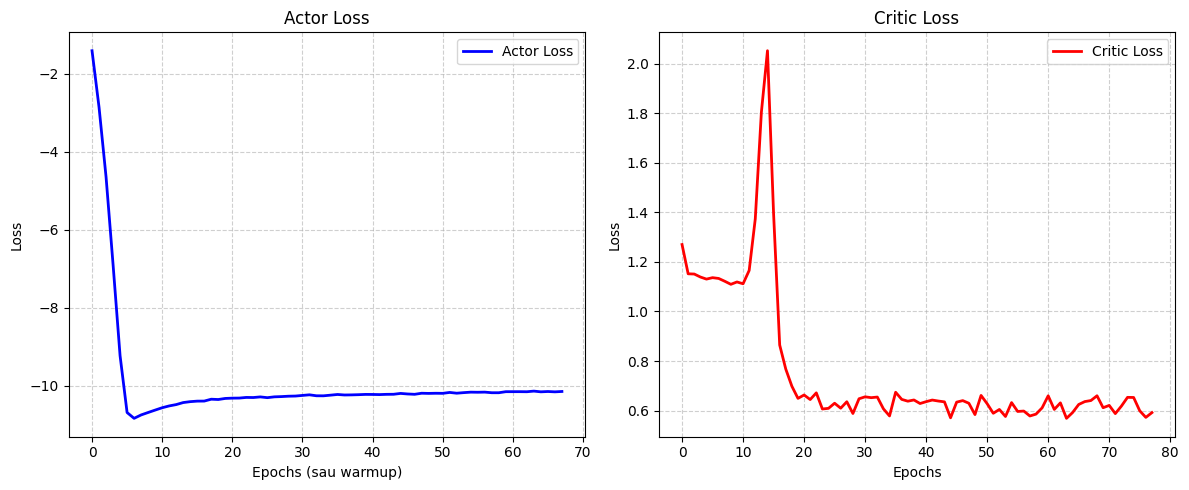

NameError: name 'evaluate_rl_actor' is not defined

In [20]:
test_data = prepare_rl_test_data(RATING_FILE_PATH, max_seq_len=200)
device = 'cuda'
trained_actor, active_encoder = train_rl_model(
    data,
    model,
    device=device,
    epochs=100,
    batch_size=256,
    test_data=test_data,
    patience=8,      # FIX 4: tăng từ 3 → 8
    val_every=3,     # FIX 3: validate mỗi 3 epoch
)

# SAU KHI TRAIN XONG: chạy full-rank evaluation để có số chính thức
full_metrics, n_test = evaluate_rl_actor(
    active_encoder, trained_actor, test_data, device, ks=(1, 5, 10)
)
print("Full-rank NDCG@10:", full_metrics['NDCG@10'])

torch.save(trained_actor.state_dict(), "rl_actor_final.pth")

In [ ]:
# # 2. Train
# # trained_actor, active_encoder = train_rl_model(data, model, device='cuda', epochs=10)
# # Chạy 1 lần — mất ~5-10 phút nhưng tiết kiệm toàn bộ thời gian các epoch sau
# test_data = prepare_rl_test_data(RATING_FILE_PATH, max_seq_len=200)
# trained_actor, active_encoder = train_rl_model(
#     data, model, device='cuda', epochs=100, test_data=test_data, patience=10
# )
# # 3. Lưu model
# torch.save(trained_actor.state_dict(), "rl_actor_final.pth")
# print("✅ Đã lưu model!")

#  TEST AND VALIDATE

In [ ]:
#====================================================================
# 3. CHẠY ĐÁNH GIÁ
# ====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    if 'active_encoder' not in locals() or 'trained_actor' not in locals():
        print("[!] Cảnh báo: Biến 'active_encoder' hoặc 'trained_actor' chưa được tạo.")
        print("    Hãy chạy lại ô train_rl_model trước.")
    else:
        RATING_FILE_PATH = r'F:\1_REL\Reinforcement-learning-for-Recommendation\Data_Movielens_1m\ml-1m\ratings.dat'

        test_data = prepare_rl_test_data(RATING_FILE_PATH, max_seq_len=200)

        rl_metrics, rl_n_test = evaluate_rl_actor(
            active_encoder, trained_actor, test_data, device, ks=(1, 5, 10)
        )

        N_ITEMS = active_encoder.bert.item_embedding.weight.shape[0] - 1

        print("\n" + "=" * 55)
        print("KẾT QUẢ FULL-RANK EVALUATION")
        print("=" * 55)
        for k in ['Hit@1', 'Hit@5', 'Hit@10', 'NDCG@1', 'NDCG@5', 'NDCG@10']:
            print(f"  {k:<10}: {rl_metrics[k]:.4f}")
        print(f"  (Tổng users: {rl_n_test:,} | Catalog: {N_ITEMS} items)")
        print("-" * 55)

except Exception as e:
    print(f"Có lỗi xảy ra: {e}")

[*] Đang chuẩn bị tập Test (Chỉ lấy Target >= 4 sao) từ F:\1_REL\Reinforcement-learning-for-Recommendation\Data_Movielens_1m\ml-1m\ratings.dat ...
[+] Hoàn tất! Đã tạo tập Test cho 6,038 người dùng hợp lệ.
[*] Full-rank evaluation | 6038 users | Catalog: 3707 items


Full-rank Evaluating: 100%|██████████| 6038/6038 [01:08<00:00, 88.77it/s] 


KẾT QUẢ FULL-RANK EVALUATION
  Hit@1     : 0.0477
  Hit@5     : 0.1597
  Hit@10    : 0.2549
  NDCG@1    : 0.0477
  NDCG@5    : 0.1038
  NDCG@10   : 0.1346
  (Tổng users: 6,038 | Catalog: 3707 items)
-------------------------------------------------------


In [ ]:
# ====================================================================
# EVALUATE RL_ACTOR_BEST.PTH
# ====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tải model tốt nhất
best_actor_path = "rl_actor_best.pth"
best_actor = Actor(state_dim=64, action_dim=64, beta=0.5).to(device)
best_actor.load_state_dict(torch.load(best_actor_path, map_location=device))
print(f"[+] Đã tải model từ {best_actor_path}")

# Chuẩn bị test data
test_data = prepare_rl_test_data(RATING_FILE_PATH, max_seq_len=200)

# Đánh giá với sampled evaluation (nhanh)
print(f"\n[*] Đang đánh giá trên {len(test_data)} users...")
metrics_sampled, n_test_sampled = evaluate_rl_actor_sampled(
    active_encoder, best_actor, test_data, device,
    ks=(1, 5, 10), n_negatives=100, max_users=500
)

print("\n" + "="*60)
print("KẾT QUẢ ĐÁNH GIÁ (SAMPLED - 500 users, 100 negatives)")
print("="*60)
for k in ['Hit@1', 'Hit@5', 'Hit@10', 'NDCG@1', 'NDCG@5', 'NDCG@10']:
    print(f"  {k:<10}: {metrics_sampled[k]:.4f}")
print(f"  (Test users: {n_test_sampled})")
print("="*60)

C:\Users\TanPhat\AppData\Local\Temp\ipykernel_10256\1225098539.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_actor.load_state_dict(torch.load(best_actor_path, map

[+] Đã tải model từ rl_actor_best.pth
[*] Đang chuẩn bị tập Test (Chỉ lấy Target >= 4 sao) từ F:\1_REL\Reinforcement-learning-for-Recommendation\Data_Movielens_1m\ml-1m\ratings.dat ...
[+] Hoàn tất! Đã tạo tập Test cho 6,038 người dùng hợp lệ.

[*] Đang đánh giá trên 6038 users...

KẾT QUẢ ĐÁNH GIÁ (SAMPLED - 500 users, 100 negatives)
  Hit@1     : 0.2120
  Hit@5     : 0.5540
  Hit@10    : 0.7200
  NDCG@1    : 0.2120
  NDCG@5    : 0.3893
  NDCG@10   : 0.4429
  (Test users: 500)


: 